## Problem 1

In [1]:
import pandas as pd

CREDIT_CARD_DATA_CSV= 'creditcard_dataset.csv'

df = pd.DataFrame()
df = pd.read_csv(CREDIT_CARD_DATA_CSV)    

# Sanity
print(f'#rows={len(df)} #columns={len(df.columns)}')
df.head()

#rows=8950 #columns=18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


We see the data id 8950x18 with rows per customer where each customer has a unique id. Balance, purchase, and payment summary info is captured in each row.

## Problem 2

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

We already found the dimensions in problem 1. Looking at the columns, the only nominal feature appears to be CUST_ID which could be removed.

In [3]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

We have 1 NaN value in CREDIT_LIMIT and 313 NaN values in MINIMUM_PAYMENTS

## Problem 3

We start by dropping the nominal feature, CUST_ID, and using median to fill the NaN values.

In [4]:
df = df.drop(columns=["CUST_ID"])

df = df.fillna(df.median())

Next, we use StandardScaler to scale the features.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Problem 4

In [6]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=5,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)
print(f"BIC={gmm.bic(X_scaled):.2f}")

BIC=-193653.67


In [7]:
synthetic_samples, component_labels = gmm.sample(n_samples=1000)

print("Synthesized shape:", synthetic_samples.shape)

Synthesized shape: (1000, 17)


The synthesized array has shape (1000, 17), which is 1000 synthetic customer records with 17 scaled features.

Next, we try other component counts.

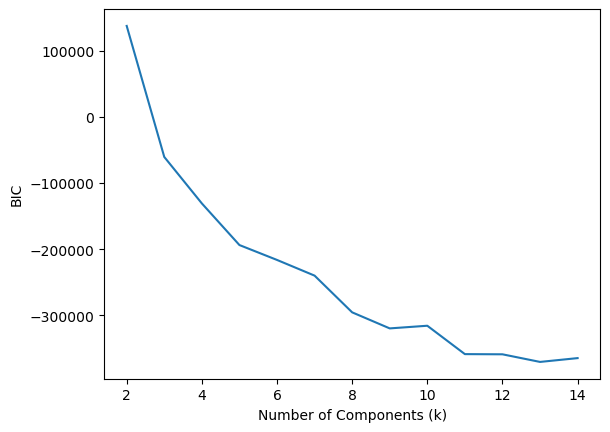

In [8]:
import matplotlib.pyplot as plt

ks = range(2, 15)
bics = []

for k in ks:
    gmm2 = GaussianMixture(n_components=k, random_state=42)
    gmm2.fit(X_scaled)
    bics.append(gmm2.bic(X_scaled))

plt.plot(ks, bics)
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC")
plt.show()


Most improvement happens before k=8, so we might pick between 8 and 10 components. 

## Problem 5

In [9]:
synthetic_original = scaler.inverse_transform(synthetic_samples)

synthetic_df = pd.DataFrame(
    synthetic_original,
    columns=df.columns
)

print("Shape:", synthetic_df.shape)
synthetic_df.head()

Shape: (1000, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3155.303539,1.134168,-147.992892,-324.204008,174.658207,1978.884090,0.742519,0.431050,0.274051,0.378179,14.876123,16.849227,-136.330525,1950.958813,1058.710762,-0.303957,9.978349
1,3887.334437,0.941211,1414.397927,1268.555208,146.331565,-717.430185,0.877385,0.367754,0.823833,0.281255,7.039411,32.235981,4013.765477,-96.359071,1734.875243,0.276117,13.012192
2,1400.837968,0.774484,2303.580145,1102.392113,1202.132996,2328.606221,0.933923,0.606160,0.720439,0.090844,13.881969,33.799356,5169.716101,2655.347258,445.458350,0.182393,10.142778
3,-511.068101,0.705993,2101.926741,984.223723,1120.047581,-1313.042265,0.875148,0.461274,0.465711,0.115424,1.238420,44.212523,2721.483014,1464.799956,-422.284213,0.351203,12.109698
4,-294.775312,0.966301,1144.626380,437.571601,705.052098,-103.225609,0.961740,0.241604,0.940662,0.238695,13.901741,21.228184,3464.106676,1094.936854,442.140733,0.360102,12.199081


Visual inspection supports that the GMM steps have not changed the order of the original dimensions or feature orderings.

## Problem 6

In [10]:
print("Original CREDIT_LIMIT min:", df['CREDIT_LIMIT'].min())
print("Original CREDIT_LIMIT max:", df['CREDIT_LIMIT'].max())

print("Synthetic CREDIT_LIMIT min:", synthetic_df['CREDIT_LIMIT'].min())
print("Synthetic CREDIT_LIMIT max:", synthetic_df['CREDIT_LIMIT'].max())

Original CREDIT_LIMIT min: 50.0
Original CREDIT_LIMIT max: 30000.0
Synthetic CREDIT_LIMIT min: -5212.847864020801
Synthetic CREDIT_LIMIT max: 16436.440170993825


The synthesized min, -5212.8, is negative which does not seem realistic. Also, the max is shifted quite a bit from 30K in the original to 16K in the synthetic.

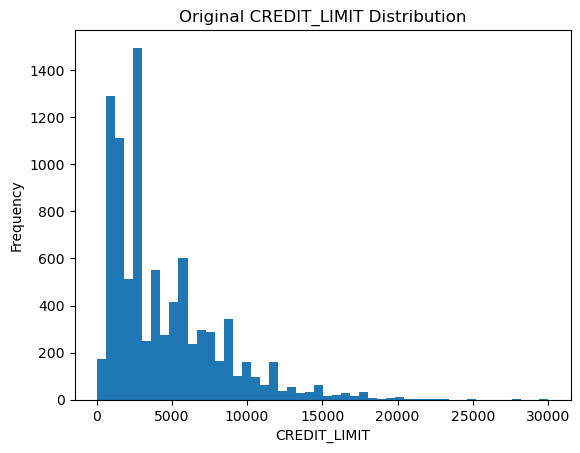

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['CREDIT_LIMIT'], bins=50)
plt.xlabel('CREDIT_LIMIT')
plt.ylabel('Frequency')
plt.title('Original CREDIT_LIMIT Distribution')
plt.show()

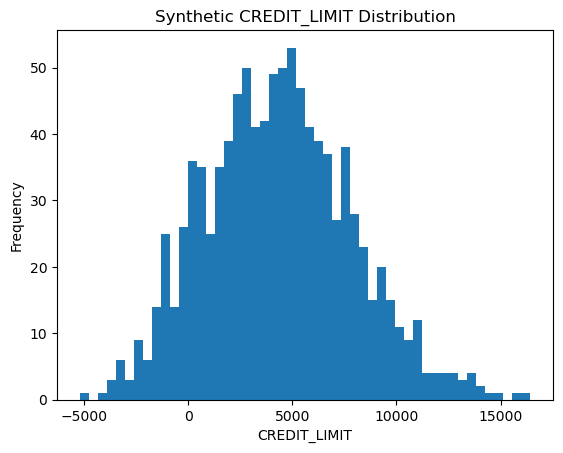

In [12]:
plt.figure()
plt.hist(synthetic_df['CREDIT_LIMIT'], bins=50)
plt.xlabel('CREDIT_LIMIT')
plt.ylabel('Frequency')
plt.title('Synthetic CREDIT_LIMIT Distribution')
plt.show()

The original plot has a strong right skew with spikes around common credit limits. It is strictly positive and is not symmetric.

The synthetic plot is centered around 5000 with more of a Gaussian distribution (roughly bell shaped) and includes negative values which are not realistic. It appears to misrepresent the heavy tail from the original. This shows some limitations of GMM including not enforcing domain constraints, misrepresenting highly skewed data, and assuming Gaussian components.

## Problem 7

As noted above, the big difference in Q6 comes because GMM assumes Gaussian components and CREDIT_LIMIT is not Gaussian; it is highly skewed and bounded. So, assuming a Gaussian distribution for all features was incorrect.

In [13]:
from distfit import distfit
import pandas as pd

dist_models = {}

synthetic_independent = pd.DataFrame()

N = 1000

for col in df.columns:
    dfit = distfit(verbose=0)
    dfit.fit_transform(df[col])
    
    dist_models[col] = dfit
    
    synthetic_independent[col] = dfit.generate(N)

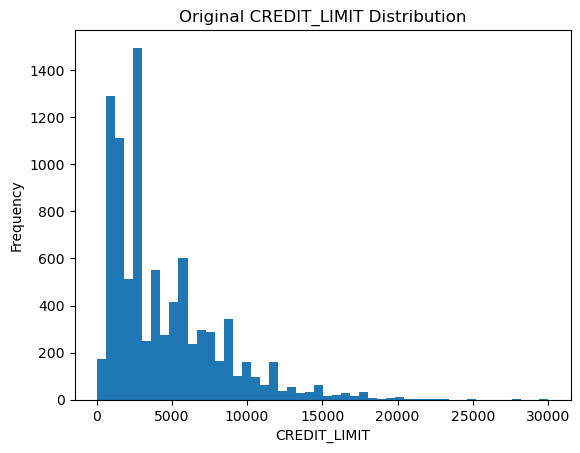

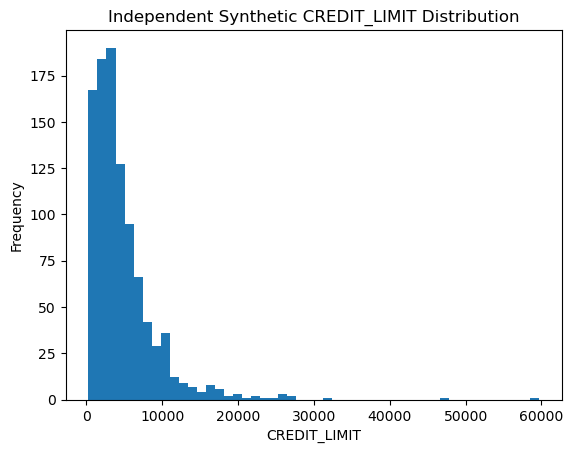

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['CREDIT_LIMIT'], bins=50)
plt.title('Original CREDIT_LIMIT Distribution')
plt.xlabel('CREDIT_LIMIT')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.hist(synthetic_independent['CREDIT_LIMIT'], bins=50)
plt.title('Independent Synthetic CREDIT_LIMIT Distribution')
plt.xlabel('CREDIT_LIMIT')
plt.ylabel('Frequency')
plt.show()

By building separate distributions per feature, we get a much closer match for CREDIT_LIMIT. The downside of this approach is we lose correlation structure between features, e.g., the relationship between balance and credit limit. 

## Problem 8 [Project Work]

### Research Topic - Solver Log Copilot

Modern MIP/LP solvers (e.g., Rose, Gurobi, CPLEX, HiGHS) generate long, unstructured logs containing presolve statistics, heuristic activity, branching behavior, cut generation, and numerical warnings. Interpreting these logs to diagnose why a solve was slow or unsuccessful requires deep solver expertise and significant manual effort. Build a system to act as an “AI copilot” for optimization practitioners.

### Summaries

#### 1. LLM-based event log analysis techniques

This paper surveys how Large Language Models (LLMs) are being applied to event log analysis, particularly in system reliability and software engineering contexts.

The main problems addressed are that manual log analysis is:

- Time-consuming
- Error-prone
- Requires expert knowledge
- Hard to scale across systems

And that traditional ML approaches for log analysis:

- Require heavy feature engineering
- Depend on log parsing
- Struggle with unstructured or evolving log formats

Since this is a survey, it categorizes LLM usage rather than proposes a new method. The categorization is:
- Fine-tuning approaches
- In-context learning
- Retrieval-Augmented Generation (RAG)
- Hybrid symbolic–LLM systems


One of the key findings that RAG is strongly preferred over fine-tuning as fine-tuning LLMs on logs is expensive and brittle. RAG performs well with smaller data and reduces hallucination risk.

Another key finding relevant to my project is that log analysis evaluation often lacks "ground truth" and human judgment is still required, meaning the co-pilot will need to be used to supplement, not replace human reasoning. Also, I'll likely need to make sure I provide some set of human labelled logs.

A minor but still important note, the paper also indicates I may need to compress logs before feeding to the model depending on size. 

The survey reports that:
- LLM-based approaches reduce manual log analysis time significantly
- RAG reduces hallucinations compared to vanilla prompting
- Fine-tuned LLMs outperform classical ML models on structured tasks
- LLMs handle unseen log formats better than static models

Since this is a survey, it does not include quantitative results other than log anomaly detection F1 often being 0.85–0.98 on benchmark datasets.


##### Reference
S. Akhtar, S. Khan, and S. Parkinson, “LLM-based event log analysis techniques: A survey,”
arXiv preprint arXiv:2502.00677, 2025. [Online]. Available: https://arxiv.org/abs/2502.00677

#### 2. Deep learning for anomaly detection in log data

The authors cover log anomaly detection for:

- System failures
- Incidents
- Intrusions
- Operational breakdowns

They point out that rraditional methods struggle with:

- High dimensionality
- Evolving log templates
- Long-term dependencies
- Imbalanced datasets (few anomalies)

The methods reviewed are:
- Log Parsing + Feature Engineering, e.g, event sequence modelling
- Sequence-Based Models (LSTM, GRU, Transformer Architectures, Next-event prediction models)
- Reconstruction Based Models (Autoencoders, VAEs)
- Graph-based methods

Some of the performance claims are:

- Deep models outperform classical statistical anomaly detectors
- Transformer models outperform LSTMs in long-range dependency modeling
- Autoencoders are effective but less interpretable
- Sequence-based probability modeling performs well in anomaly detection

Common evaluation metrics are:
- Precision
- Recall
- F1 score
- ROC-AUC

Reported performance ranges (from surveyed studies)
- Deep LSTM-based models: F1 ≈ 0.90–0.98
- Transformer-based models: F1 often >0.95
- Autoencoder methods: strong recall, sometimes lower precision
- Classical ML methods: typically lower than deep models

Some key takeaways specific to my project:
- Solver logs are semi-structured, so I'll likely need to extract structured features (node count progression, gap trend) and combine structured and text embeddings.
- Since they find that sequence-based modeling performs well for anomaly detection, I'll likely look at transformers.


##### Reference
M. Landauer, S. Onder, F. Skopik, and M. Wurzenberger, “Deep learning for anomaly detection
in log data: A survey,” Machine Learning with Applications, vol. 12, p. 100470, 2023. [Online].
Available: https://www.sciencedirect.com/science/article/pii/S2666827023000233

#### 3. Machine learning for combinatorial optimization

Combinatorial optimization solvers rely heavily on:

- Hand-designed heuristics
- Branching rules
- Cut selection
- Parameter tuning

These decisions are instance-dependent and hard to optimize globally. The paper addresses how machine learning can assist combinatorial optimization solvers by learning decision policies.

The paper categorizes ML usage into:

- Learning to Configure (parameter tuning, solver selection)
- Learning to Guide Search (branching policies, cut selection, node selection)
- Learning Surrogate Models (predict solver run time, node counts, performance metrics)
- Reinforcement Learning (learning search policies and decision sequences)


It makes the following performance claims:

- Learned branching can outperform handcrafted heuristics (cites 10–30% runtime reductions)
- ML-based solver configuration can reduce runtime significantly
- Surrogate models can predict runtime and difficulty with reasonable accuracy
- Hybrid ML + solver systems often outperform pure heuristic approaches

And calls out that:
- Generalization remains difficult
- Training cost can be high
- Interpretability is often limited

For my project, this paper emphasizes that ML-driven solver diagnostics and control are important research directions. Specifically, ML is good at decision-making under uncertainty which can help out with solvers that have expensive heuristics. I might be able to recommend cut aggressiveness, heuristic settings, and/or presolve adjustments based on what is learned from log data.

##### Reference
Y. Bengio, A. Lodi, and A. Prouvost, “Machine learning for combinatorial optimization: A
methodological tour d’horizon,” arXiv preprint arXiv:1811.06128, 2018. [Online]. Available:
https://arxiv.org/abs/1811.06128